Weekly revenue is modeled as the sum of baseline demand, trend, promotion, yearly seasonality, and channel-specific media contributions after geometric adstock and logistic saturation.

$$ y_t \sim \mathcal{N}(\mu_t, \sigma) $$

$$ \mu_t = \alpha + \gamma_1 \,\text{promotion}_t + \gamma_2 \,\text{time\_index}_t +\text{seasonality}_t+ \sum_{m=1}^{3} \beta_m S_{\lambda_m} \left( A_{\alpha_m}(x_{t,m}) \right) $$

In [1]:
%pip install -U ipywidgets


[notice] A new release of pip is available: 24.3.1 -> 26.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [6]:
import pandas as pd

from pymc_marketing.mmm import (GeometricAdstock, LogisticSaturation,)
from pymc_marketing.mmm.multidimensional import MMM

RANDOM_SEED = 20260801

train_df = pd.read_csv( "../data/scenario_a/scenario_a_train.csv", parse_dates=["date_week"],)

channel_columns = [ "tv_spend",   "google_search_spend",  "tiktok_spend", ]
control_columns = [  "promotion", "time_index", ]

X_train = train_df[ ["date_week", *channel_columns,  *control_columns, ] ].copy()
y_train = train_df["revenue"].copy()

mmm = MMM(
    date_column="date_week",
    target_column="revenue",
    channel_columns=channel_columns,
    control_columns=control_columns,
    adstock=GeometricAdstock(l_max=8),
    saturation=LogisticSaturation(),
    yearly_seasonality=2,
)
mmm

The standard PyMC-marketing MMM accepts one shared adstock transformation, so l_max is common across channels. Channel specific carryover is mainly captured through different adstock decay parameters. Exact channel specific maximum lags require a lower-level mediaconfiglist setup and a customized PyMC model.

l_max is a structural modeling choice rather than a parameter estimated by NUTS. The decay parameter is inferred from the data conditional on that maximum lag. I would choose a defensible baseline using domain knowledge, then compare alternative lag windows through time-based validation, residual diagnostics, and sensitivity analysis.

In [7]:
mmm.build_model(
    X=X_train,
    y=y_train,
)

print(mmm.model)

print("Coordinates:")
display(mmm.model.coords)

print("Named variables:")
for variable_name in mmm.model.named_vars:
    print(variable_name)

Coordinates:


{'date': (np.datetime64('2023-01-02T00:00:00.000000'),
  np.datetime64('2023-01-09T00:00:00.000000'),
  np.datetime64('2023-01-16T00:00:00.000000'),
  np.datetime64('2023-01-23T00:00:00.000000'),
  np.datetime64('2023-01-30T00:00:00.000000'),
  np.datetime64('2023-02-06T00:00:00.000000'),
  np.datetime64('2023-02-13T00:00:00.000000'),
  np.datetime64('2023-02-20T00:00:00.000000'),
  np.datetime64('2023-02-27T00:00:00.000000'),
  np.datetime64('2023-03-06T00:00:00.000000'),
  np.datetime64('2023-03-13T00:00:00.000000'),
  np.datetime64('2023-03-20T00:00:00.000000'),
  np.datetime64('2023-03-27T00:00:00.000000'),
  np.datetime64('2023-04-03T00:00:00.000000'),
  np.datetime64('2023-04-10T00:00:00.000000'),
  np.datetime64('2023-04-17T00:00:00.000000'),
  np.datetime64('2023-04-24T00:00:00.000000'),
  np.datetime64('2023-05-01T00:00:00.000000'),
  np.datetime64('2023-05-08T00:00:00.000000'),
  np.datetime64('2023-05-15T00:00:00.000000'),
  np.datetime64('2023-05-22T00:00:00.000000'),
  np.

Named variables:
channel_scale
target_scale
channel_data
target_data
intercept_contribution
adstock_alpha
saturation_lam
saturation_beta
channel_contribution
total_media_contribution_original_scale
gamma_control
control_data
control_contribution
dayofyear
gamma_fourier
fourier_contribution
yearly_seasonality_contribution
y_sigma
y


The model configuration defines priors for the intercept, control and seasonal effects, channel-specific adstock and saturation parameters, and the observation noise in the likelihood.

In [8]:
display(mmm.model_config)

{'intercept': Prior("Normal", mu=0, sigma=2, dims=()),
 'likelihood': Prior("Normal", sigma=Prior("HalfNormal", sigma=2, dims=()), dims="date"),
 'gamma_control': Prior("Normal", mu=0, sigma=2, dims="control"),
 'gamma_fourier': Prior("Laplace", mu=0, b=1, dims="fourier_mode"),
 'adstock_alpha': Prior("Beta", alpha=1, beta=3, dims="channel"),
 'saturation_lam': Prior("Gamma", alpha=3, beta=1, dims="channel"),
 'saturation_beta': Prior("HalfNormal", sigma=2, dims="channel")}

Prior predictive checks help verify that the priors imply plausible business outcomes before fitting the model.

In [9]:
_ = mmm.sample_prior_predictive(
    X=X_train,
    y=y_train,
    samples=500,
    random_seed=RANDOM_SEED,
)

Sampling: [adstock_alpha, gamma_control, gamma_fourier, intercept_contribution, saturation_beta, saturation_lam, y, y_sigma]


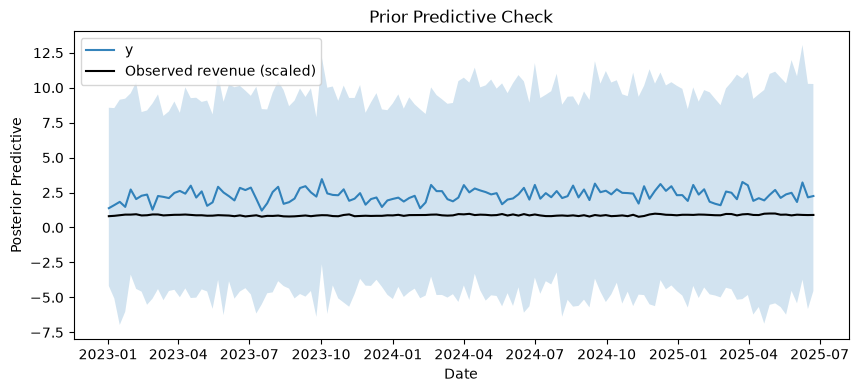

In [16]:
fig, axes = mmm.plot.prior_predictive(hdi_prob=0.94)

ax = axes.flatten()[0]

ax.plot(
    X_train["date_week"],
    y_train / y_train.max(),
    color="black",
    linewidth=1.5,
    label="Observed revenue (scaled)",
)

ax.set_title("Prior Predictive Check")
ax.legend()

The observed revenue falls within the prior predictive interval, but the default priors are quite broad and allow implausibly negative and very large outcomes.

In [18]:
mmm.fit(
    X=X_train,
    y=y_train,
    chains=4,
    tune=1000,
    draws=1000,
    target_accept=0.95,
    random_seed=RANDOM_SEED,
)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [intercept_contribution, adstock_alpha, saturation_lam, saturation_beta, gamma_control, gamma_fourier, y_sigma]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 69 seconds.
There were 22 divergences after tuning. Increase `target_accept` or reparameterize.


Output()

Inference data with groups:
	> posterior
	> sample_stats
	> prior
	> prior_predictive
	> observed_data
	> constant_data
	> fit_data

In [19]:
mmm.fit(
    X=X_train,
    y=y_train,
    chains=4,
    tune=1500,
    draws=1000,
    target_accept=0.95,
    random_seed=RANDOM_SEED,
)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [intercept_contribution, adstock_alpha, saturation_lam, saturation_beta, gamma_control, gamma_fourier, y_sigma]


Output()

Sampling 4 chains for 1_500 tune and 1_000 draw iterations (6_000 + 4_000 draws total) took 81 seconds.
There were 33 divergences after tuning. Increase `target_accept` or reparameterize.


Output()

Inference data with groups:
	> posterior
	> sample_stats
	> prior
	> prior_predictive
	> observed_data
	> constant_data
	> fit_data

In [20]:
mmm.fit(
    X=X_train,
    y=y_train,
    chains=4,
    tune=1500,
    draws=500,
    target_accept=0.99,
    random_seed=RANDOM_SEED,
)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [intercept_contribution, adstock_alpha, saturation_lam, saturation_beta, gamma_control, gamma_fourier, y_sigma]


Output()

Sampling 4 chains for 1_500 tune and 500 draw iterations (6_000 + 2_000 draws total) took 105 seconds.
There were 4 divergences after tuning. Increase `target_accept` or reparameterize.


Output()

Inference data with groups:
	> posterior
	> sample_stats
	> prior
	> prior_predictive
	> observed_data
	> constant_data
	> fit_data

Increasing target_accept from 0.95 to 0.99 substantially reduced the divergence rate, but four post-warmup divergences remained, so the sampling configuration still required refinement.

In [21]:
mmm.fit(
    X=X_train,
    y=y_train,
    chains=4,
    tune=2000,
    draws=1000,
    target_accept=0.995,
    random_seed=RANDOM_SEED,
)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [intercept_contribution, adstock_alpha, saturation_lam, saturation_beta, gamma_control, gamma_fourier, y_sigma]


Output()

Sampling 4 chains for 2_000 tune and 1_000 draw iterations (8_000 + 4_000 draws total) took 220 seconds.
There were 10 divergences after tuning. Increase `target_accept` or reparameterize.


Output()

Inference data with groups:
	> posterior
	> sample_stats
	> prior
	> prior_predictive
	> observed_data
	> constant_data
	> fit_data

Divergences: 10/4000 (0.25%)


,mean,sd,r_hat,ess_bulk,ess_tail
adstock_alpha[tv_spend],0.370,0.109,1.000,3433.007,2012.797
adstock_alpha[google_search_spend],0.250,0.182,1.001,3110.605,1888.956
adstock_alpha[tiktok_spend],0.173,0.127,1.001,3601.515,1941.009
saturation_lam[tv_spend],2.037,1.372,0.999,2053.723,1451.782
saturation_lam[google_search_spend],2.993,2.101,1.006,715.694,484.768
saturation_lam[tiktok_spend],1.777,1.253,1.001,2226.913,2048.783
saturation_beta[tv_spend],0.165,0.198,1.000,1871.345,1432.596
saturation_beta[google_search_spend],0.115,0.121,1.006,837.079,453.220
saturation_beta[tiktok_spend],0.100,0.117,1.002,2128.671,2116.304
gamma_control[promotion],0.075,0.006,1.000,4769.112,3071.445


BFMI by chain:
[0.87770669 0.93794124 0.87175187 0.84315262]


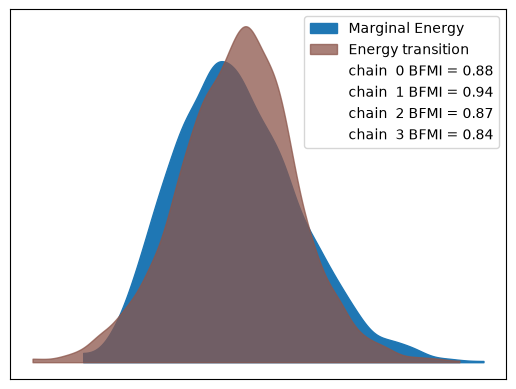

In [22]:
import arviz as az

idata = mmm.idata

n_divergences = int(
    idata["sample_stats"]["diverging"].sum().item()
)

n_samples = (
    idata["sample_stats"].sizes["chain"]
    * idata["sample_stats"].sizes["draw"]
)

print(
    f"Divergences: {n_divergences}/{n_samples} "
    f"({n_divergences / n_samples:.2%})"
)

diagnostic_vars = [
    "adstock_alpha",
    "saturation_lam",
    "saturation_beta",
    "gamma_control",
    "gamma_fourier",
    "y_sigma",
]

summary = az.summary(
    idata,
    var_names=diagnostic_vars,
    round_to=3,
)

display(
    summary[
        [
            "mean",
            "sd",
            "r_hat",
            "ess_bulk",
            "ess_tail",
        ]
    ]
)

print("BFMI by chain:")
print(az.bfmi(idata))

az.plot_energy(idata);

I did not conclude that the entire Google Search channel was problematic. I identified its saturation parameters as the first candidates for investigation because they had the highest R-hat values and substantially lower bulk and tail ESS than the corresponding parameters for TV and TikTok.

Divergences by chain:
[0 6 1 3]


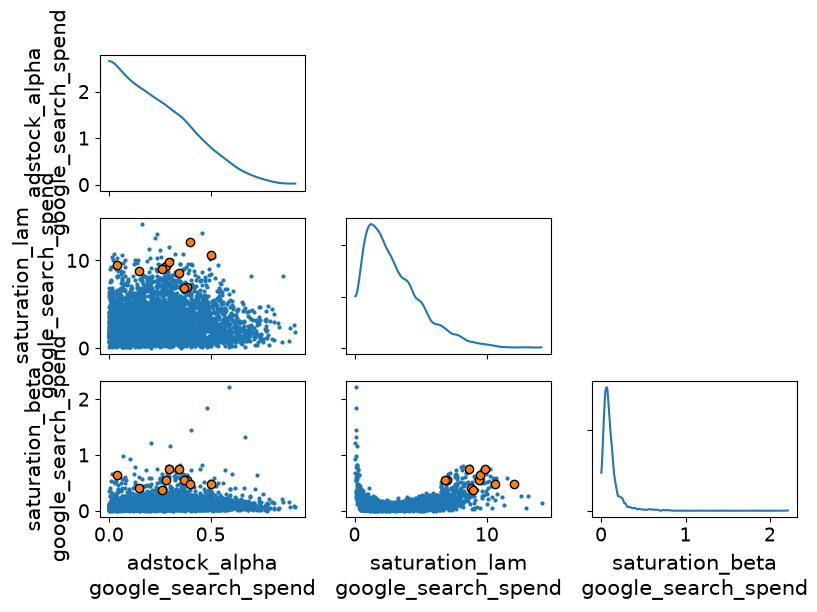

In [28]:
idata = mmm.idata

print("Divergences by chain:")
print(
    idata["sample_stats"]["diverging"]
    .sum(dim="draw")
    .values
)

az.plot_pair(
    idata,
    var_names=[
        "adstock_alpha",
        "saturation_lam",
        "saturation_beta",
    ],
    coords={
        "channel": ["google_search_spend"]
    },
    kind="scatter",
    marginals=True,
    divergences=True,
    figsize=(9, 6),
);

The pair plot shows a strong nonlinear dependence between the Google Search saturation parameters. Different combinations of saturation_lam and saturation_beta appear to produce similar response curves within the observed spend range. The divergent transitions are concentrated in the high-lambda and moderate-to-high-beta region, indicating a localized posterior geometry and weak-identification problem rather than overall chain non-convergence.

## Regularized Model

In [32]:
from pymc_extras.prior import Prior

In [33]:
regularized_model_config = {
    "saturation_beta": Prior(
        "HalfNormal",
        sigma=0.3,
        dims="channel",
    ),
    "saturation_lam": Prior(
        "Gamma",
        mu=3.0,
        sigma=1.0,
        dims="channel",
    ),
}

In [34]:
mmm_regularized = MMM(
    date_column="date_week",
    target_column="revenue",
    channel_columns=channel_columns,
    control_columns=control_columns,
    adstock=GeometricAdstock(l_max=8),
    saturation=LogisticSaturation(),
    yearly_seasonality=2,
    model_config=regularized_model_config,
)

In [35]:
mmm_regularized.build_model(
    X=X_train,
    y=y_train,
)

display(mmm_regularized.model_config)

{'intercept': Prior("Normal", mu=0, sigma=2, dims=()),
 'likelihood': Prior("Normal", sigma=Prior("HalfNormal", sigma=2, dims=()), dims="date"),
 'gamma_control': Prior("Normal", mu=0, sigma=2, dims="control"),
 'gamma_fourier': Prior("Laplace", mu=0, b=1, dims="fourier_mode"),
 'adstock_alpha': Prior("Beta", alpha=1, beta=3, dims="channel"),
 'saturation_lam': Prior("Gamma", mu=3.0, sigma=1.0, dims="channel"),
 'saturation_beta': Prior("HalfNormal", sigma=0.3, dims="channel")}

In [36]:
_ = mmm_regularized.sample_prior_predictive(
    X=X_train,
    y=y_train,
    samples=500,
    random_seed=RANDOM_SEED,
)

Sampling: [adstock_alpha, gamma_control, gamma_fourier, intercept_contribution, saturation_beta, saturation_lam, y, y_sigma]


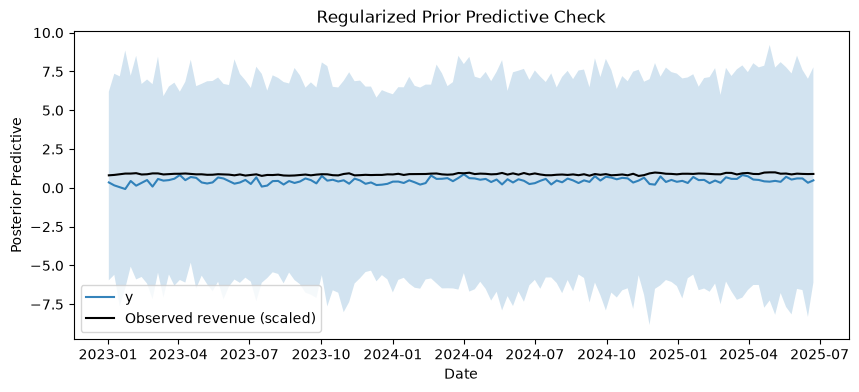

In [37]:
fig, axes = mmm_regularized.plot.prior_predictive(
    hdi_prob=0.94
)

ax = axes.flatten()[0]

ax.plot(
    X_train["date_week"],
    y_train / y_train.max(),
    color="black",
    linewidth=1.5,
    label="Observed revenue (scaled)",
)

ax.set_title("Regularized Prior Predictive Check")
ax.legend();

In [47]:
mmm_regularized.fit(
    X=X_train,
    y=y_train,
    chains=4,
    tune=1500,
    draws=1000,
    target_accept=0.99,
    random_seed=RANDOM_SEED,
)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [intercept_contribution, adstock_alpha, saturation_lam, saturation_beta, gamma_control, gamma_fourier, y_sigma]


Output()

Sampling 4 chains for 1_500 tune and 1_000 draw iterations (6_000 + 4_000 draws total) took 89 seconds.


Output()

Inference data with groups:
	> posterior
	> sample_stats
	> prior
	> prior_predictive
	> observed_data
	> constant_data
	> fit_data

In [48]:
diagnostic_vars = [
    "adstock_alpha",
    "saturation_lam",
    "saturation_beta",
    "gamma_control",
    "gamma_fourier",
    "y_sigma",
]

regularized_summary = az.summary(
    mmm_regularized.idata,
    var_names=diagnostic_vars,
    round_to=3,
)

display(
    regularized_summary[
        [
            "mean",
            "sd",
            "r_hat",
            "ess_bulk",
            "ess_tail",
        ]
    ]
)

print("BFMI by chain:")
print(az.bfmi(mmm_regularized.idata))

,mean,sd,r_hat,ess_bulk,ess_tail
adstock_alpha[tv_spend],0.363,0.110,1.001,3729.113,2394.416
adstock_alpha[google_search_spend],0.245,0.179,1.001,3104.579,1795.364
adstock_alpha[tiktok_spend],0.176,0.129,1.000,3228.786,1892.750
saturation_lam[tv_spend],2.690,0.910,1.001,2869.663,2469.990
saturation_lam[google_search_spend],2.995,1.078,1.001,3209.964,1903.699
saturation_lam[tiktok_spend],2.550,0.883,1.000,3076.013,2784.838
saturation_beta[tv_spend],0.085,0.031,1.001,2164.306,2585.245
saturation_beta[google_search_spend],0.074,0.044,1.002,1663.921,1686.463
saturation_beta[tiktok_spend],0.052,0.018,1.001,2721.737,2379.599
gamma_control[promotion],0.074,0.006,1.001,4506.264,2892.792


BFMI by chain:
[0.93171934 0.89450938 0.94932879 0.85055827]


### MCMC Sampling Diagnostics

| Diagnostic | What it measures | Interpretation | Recommended response |
|---|---|---|---|
| **R-hat** | Compares within-chain and between-chain variation to assess whether multiple chains explored the same posterior distribution. | Values close to `1.00` are desirable. `R-hat < 1.01` is commonly treated as acceptable. A larger value suggests incomplete convergence or poor mixing. | Increase tuning, inspect trace plots, improve priors or scaling, reparameterize, or simplify the model. |
| **ESS bulk** | Estimates the effective number of independent samples in the central or high-probability region of the posterior. | A low value means strong autocorrelation and imprecise estimates of posterior means, medians, and standard deviations. Higher is better; several hundred is a rough minimum, while more than `1,000` is preferable when available. | Increase sampling only after checking mixing, parameter correlation, scaling, priors, and model geometry. |
| **ESS tail** | Estimates the effective number of independent samples in the posterior tails. | A low value means that tail probabilities, credible-interval endpoints, and extreme quantiles may be estimated unreliably. Higher is better; several hundred is a rough minimum. | Inspect skewed or heavy-tailed parameters, improve priors or parameterization, and increase draws only after addressing structural problems. |
| **Divergences** | Identify NUTS trajectories for which the numerical Hamiltonian integration becomes inaccurate, usually because of high curvature or difficult posterior geometry. | Post-warmup divergences should ideally be `0`. Even a small number can indicate biased exploration if they concentrate in an important posterior region. | Use pair plots to locate the problematic parameter combinations, inspect scaling and priors, increase `target_accept` modestly, reparameterize, or simplify the model. |

These diagnostics answer different questions:

- **R-hat:** Did the chains converge to the same posterior distribution?
- **ESS bulk:** Do I have enough effective samples for the center of the posterior?
- **ESS tail:** Do I have enough effective samples for credible intervals and tail quantities?
- **Divergences:** Did NUTS fail to explore any difficult posterior regions accurately?

ess_tail checks the effective sample size for the 5% and 95% quantiles and reports the smaller value.

These results indicate stable chain mixing, adequate effective sample sizes, and no detected divergent transitions.
### Bayesian Fraction of Missing Information (BFMI)

BFMI is an HMC/NUTS diagnostic that measures how effectively each chain explores the posterior energy distribution.

A sample-based form is:

$$\mathrm{BFMI}=\frac{\frac{1}{N-1}\sum_{n=2}^{N}(E_n-E_{n-1})^2}{\operatorname{Var}(E)},$$

where $E_n$ is the Hamiltonian energy at draw $n$.

- A low BFMI means that the chain makes only small energy transitions relative to the full posterior energy range and may fail to explore some regions.
- BFMI below approximately `0.3` is commonly treated as a warning sign.
- Values near or above `1` generally indicate good energy exploration and may occasionally be slightly greater than `1`.

In [49]:
from pathlib import Path

MODEL_PATH = Path(
    "../artifacts/mmm_regularized.nc"
)

MODEL_PATH.parent.mkdir(
    parents=True,
    exist_ok=True,
)

mmm_regularized.save(MODEL_PATH)

print(f"Model saved to: {MODEL_PATH.resolve()}")

Model saved to: /Users/hl/Desktop/PythonProject1/pymc-marketing-retail-mmm/artifacts/mmm_regularized.nc
